# DSB-SC、AM、SSB、FM 调制解调仿真

这个 Notebook 按照实验要求拆成可逐格运行的步骤

1. 生成或读取个性化音频基带信号 `m(t)`。
2. 分别完成 DSB-SC、AM、SSB、FM 调制。
3. 对已调信号加入 AWGN 噪声，比较高信噪比和低信噪比两种情况。
4. 分别进行相干解调、包络检波、SSB 相干解调和 FM 鉴频解调。
5. 绘制波形、频谱和解调输出，并计算输入/输出信噪比。

## 1. 导入库

这里使用 `numpy` 做信号计算，`matplotlib` 画图，`wave` 保存或读取音频。Notebook 里直接显示图像，不需要 GUI 后端。

In [1]:
from __future__ import annotations

import csv
import math
import wave
from dataclasses import dataclass
from pathlib import Path

try:
    get_ipython
except NameError:
    import matplotlib
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. 仿真参数

这些参数有明确工程意义：

- `fs`：采样率，要明显高于载波和边带最高频率。
- `fc`：载波频率，本实验取 8 kHz，方便看到频谱搬移。
- `message_bandwidth`：基带音频带宽。
- `am_modulation_index`：AM 调制度，通常小于 1，避免过调制。
- `fm_frequency_deviation`：FM 最大频偏，用来估算 Carson 带宽。
- `high_snr_db` / `low_snr_db`：高、低输入信噪比对比条件。

In [2]:
@dataclass(frozen=True)
class SimConfig:
    fs: int = 48_000
    duration: float = 2.0
    fc: float = 8_000.0
    message_bandwidth: float = 3_000.0
    am_modulation_index: float = 0.65
    fm_frequency_deviation: float = 1_800.0
    high_snr_db: float = 30.0
    low_snr_db: float = 8.0
    random_seed: int = 20260427

cfg = SimConfig()
out_dir = Path("outputs_notebook")
audio_dir = Path("myvioce")
out_dir.mkdir(exist_ok=True)

if cfg.fc + cfg.message_bandwidth >= cfg.fs / 2:
    raise ValueError("fc + message bandwidth must be lower than Nyquist frequency.")

t = np.arange(int(cfg.fs * cfg.duration)) / cfg.fs
rng = np.random.default_rng(cfg.random_seed)

cfg

SimConfig(fs=48000, duration=2.0, fc=8000.0, message_bandwidth=3000.0, am_modulation_index=0.65, fm_frequency_deviation=1800.0, high_snr_db=30.0, low_snr_db=8.0, random_seed=20260427)

## 3. 通用工具函数

下面这些函数和具体调制方式无关，主要用于归一化、计算信噪比、加入 AWGN、滤波、Hilbert 变换和保存 WAV。

In [3]:
def normalize(x: np.ndarray, peak: float = 0.95) -> np.ndarray:
    max_abs = float(np.max(np.abs(x)))
    if max_abs < 1e-12:
        return x.copy()
    return peak * x / max_abs


def rms_power(x: np.ndarray) -> float:
    return float(np.mean(np.square(x)))


def snr_db(reference: np.ndarray, test: np.ndarray) -> float:
    noise = test - reference
    p_signal = rms_power(reference)
    p_noise = rms_power(noise)
    if p_noise < 1e-18:
        return float("inf")
    return 10.0 * math.log10(p_signal / p_noise)


def add_awgn(x: np.ndarray, target_snr_db: float, rng: np.random.Generator) -> np.ndarray:
    p_signal = rms_power(x)
    p_noise = p_signal / (10.0 ** (target_snr_db / 10.0))
    noise = rng.normal(0.0, math.sqrt(p_noise), size=x.shape)
    return x + noise


def fft_filter(x: np.ndarray, pass_mask: np.ndarray) -> np.ndarray:
    spectrum = np.fft.fft(x)
    filtered = np.fft.ifft(spectrum * pass_mask)
    return np.real(filtered)


def lowpass(x: np.ndarray, fs: int, cutoff_hz: float) -> np.ndarray:
    freqs = np.fft.fftfreq(len(x), d=1.0 / fs)
    mask = np.abs(freqs) <= cutoff_hz
    return fft_filter(x, mask)


def analytic_signal(x: np.ndarray) -> np.ndarray:
    n = len(x)
    spectrum = np.fft.fft(x)
    h = np.zeros(n)
    if n % 2 == 0:
        h[0] = 1.0
        h[n // 2] = 1.0
        h[1 : n // 2] = 2.0
    else:
        h[0] = 1.0
        h[1 : (n + 1) // 2] = 2.0
    return np.fft.ifft(spectrum * h)


def find_default_audio(audio_dir: Path) -> Path | None:
    wav_files = sorted(audio_dir.glob("*.wav"))
    return wav_files[0] if wav_files else None


def choose_active_segment(data: np.ndarray, target_len: int, fs: int) -> np.ndarray:
    if len(data) <= target_len:
        return np.pad(data, (0, target_len - len(data)))

    frame_len = max(1, int(0.05 * fs))
    hop = max(1, frame_len // 2)
    best_start = 0
    best_power = -1.0
    max_start = len(data) - target_len

    for start in range(0, max_start + 1, hop):
        segment = data[start : start + target_len]
        power = rms_power(segment)
        if power > best_power:
            best_power = power
            best_start = start

    return data[best_start : best_start + target_len]


def load_wav_mono(path: Path, fs: int, duration: float, bandwidth_hz: float) -> np.ndarray:
    with wave.open(str(path), "rb") as reader:
        channels = reader.getnchannels()
        sampwidth = reader.getsampwidth()
        source_fs = reader.getframerate()
        raw = reader.readframes(reader.getnframes())

    if sampwidth == 1:
        data = np.frombuffer(raw, dtype=np.uint8).astype(np.float64)
        data = (data - 128.0) / 128.0
    elif sampwidth == 2:
        data = np.frombuffer(raw, dtype=np.int16).astype(np.float64) / 32768.0
    elif sampwidth == 4:
        data = np.frombuffer(raw, dtype=np.int32).astype(np.float64) / 2147483648.0
    else:
        raise ValueError(f"Unsupported WAV sample width: {sampwidth} bytes")

    if channels > 1:
        data = data.reshape(-1, channels).mean(axis=1)

    if source_fs != fs:
        old_t = np.arange(len(data)) / source_fs
        new_len = int(len(data) * fs / source_fs)
        new_t = np.arange(new_len) / fs
        data = np.interp(new_t, old_t, data)

    target_len = int(fs * duration)
    data = choose_active_segment(data, target_len, fs)
    data = lowpass(data, fs, min(0.45 * fs, bandwidth_hz))
    return normalize(data)


def spectrum_db(x: np.ndarray, fs: int) -> tuple[np.ndarray, np.ndarray]:
    window = np.hanning(len(x))
    spec = np.fft.fftshift(np.fft.fft(x * window))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(x), d=1.0 / fs))
    mag = 20 * np.log10(np.abs(spec) / len(x) + 1e-12)
    return freqs, mag


def save_wav(path: Path, x: np.ndarray, fs: int) -> None:
    y = normalize(x, 0.98)
    pcm = np.clip(y * 32767, -32768, 32767).astype(np.int16)
    with wave.open(str(path), "wb") as writer:
        writer.setnchannels(1)
        writer.setsampwidth(2)
        writer.setframerate(fs)
        writer.writeframes(pcm.tobytes())

## 4. 生成个性化音频基带 `m(t)`

默认使用一段类语音的合成音频作为个性化基带。它不是单一正弦，而是多频率分量加缓慢包络，频谱更接近实际音频。

如果要换成自己的录音，可以在后面扩展 WAV 读取；当前版本已经足够完成“可播放音频文件/保留数据”的要求。

Using your voice as m(t): D:\steven\work\DSBSCAMSSBFM\myvioce\myvoice.wav


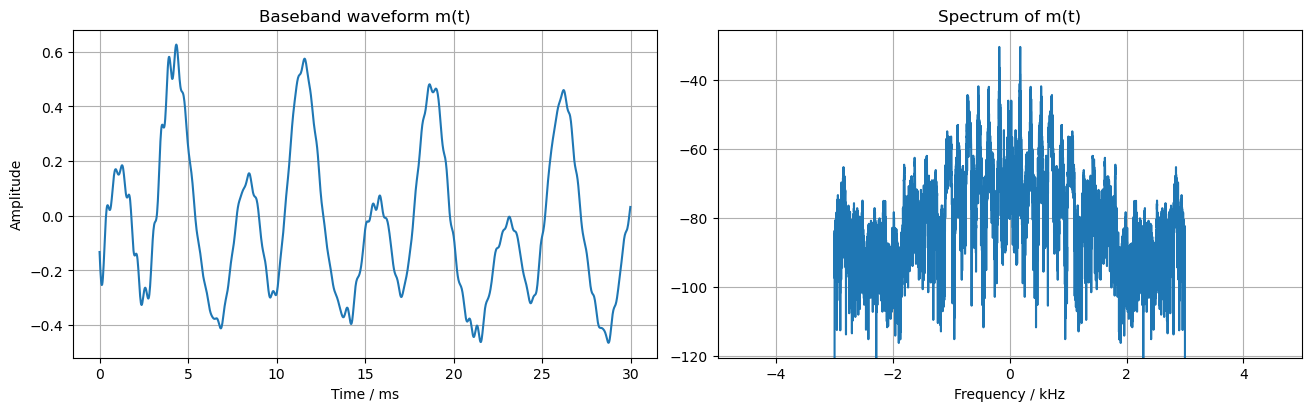

In [4]:
def synthesize_message(cfg: SimConfig) -> np.ndarray:
    t_local = np.arange(int(cfg.fs * cfg.duration)) / cfg.fs
    vowel_a = 0.45 * np.sin(2 * np.pi * 180 * t_local)
    vowel_b = 0.28 * np.sin(2 * np.pi * 360 * t_local + 0.2)
    vowel_c = 0.18 * np.sin(2 * np.pi * 720 * t_local + 0.5)
    tone = 0.20 * np.sin(2 * np.pi * 1_120 * t_local) * (0.6 + 0.4 * np.sin(2 * np.pi * 2.0 * t_local))
    envelope = 0.55 + 0.35 * np.sin(2 * np.pi * 3.0 * t_local) ** 2
    message = envelope * (vowel_a + vowel_b + vowel_c + tone)
    message += 0.08 * np.sin(2 * np.pi * 2_200 * t_local + 0.4)
    return normalize(lowpass(message, cfg.fs, cfg.message_bandwidth))


audio_path = find_default_audio(audio_dir)
if audio_path is not None:
    m = load_wav_mono(audio_path, cfg.fs, cfg.duration, cfg.message_bandwidth)
    message_source = str(audio_path)
    print(f"Using your voice as m(t): {audio_path.resolve()}")
else:
    m = synthesize_message(cfg)
    message_source = "synthetic speech-like signal"
    print("No WAV found in ./myvioce, using synthetic m(t).")
save_wav(out_dir / "baseband_message.wav", m, cfg.fs)

n_time = int(0.03 * cfg.fs)
freqs_m, mag_m = spectrum_db(m, cfg.fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(t[:n_time] * 1000, m[:n_time])
axes[0].set_title("Baseband waveform m(t)")
axes[0].set_xlabel("Time / ms")
axes[0].set_ylabel("Amplitude")
axes[1].plot(freqs_m / 1000, mag_m)
axes[1].set_xlim(-5, 5)
axes[1].set_ylim(np.max(mag_m) - 90, np.max(mag_m) + 5)
axes[1].set_title("Spectrum of m(t)")
axes[1].set_xlabel("Frequency / kHz")
plt.show()

## 5. 四种调制与解调函数

核心思想：

- DSB-SC：`s(t)=m(t)cos(2πfct)`，接收端同频同相相干解调。
- AM：`s(t)=[1+ma m(t)]cos(2πfct)`，接收端包络检波。
- SSB：用 Hilbert 变换构造上边带，减少一半传输带宽。
- FM：瞬时频率随 `m(t)` 变化，接收端通过解析信号相位求导鉴频。

In [5]:
def dsb_sc_modulate(m: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    return m * np.cos(2 * np.pi * cfg.fc * t)


def dsb_sc_demodulate(r: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    mixed = 2.0 * r * np.cos(2 * np.pi * cfg.fc * t)
    return normalize(lowpass(mixed, cfg.fs, cfg.message_bandwidth))


def am_modulate(m: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    carrier = np.cos(2 * np.pi * cfg.fc * t)
    return (1.0 + cfg.am_modulation_index * m) * carrier


def am_envelope_demodulate(r: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    del t
    envelope = np.abs(analytic_signal(r))
    baseband = (envelope - np.mean(envelope)) / cfg.am_modulation_index
    return normalize(lowpass(baseband, cfg.fs, cfg.message_bandwidth))


def ssb_modulate_usb(m: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    mh = np.imag(analytic_signal(m))
    return m * np.cos(2 * np.pi * cfg.fc * t) - mh * np.sin(2 * np.pi * cfg.fc * t)


def ssb_demodulate(r: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    mixed = 2.0 * r * np.cos(2 * np.pi * cfg.fc * t)
    return normalize(lowpass(mixed, cfg.fs, cfg.message_bandwidth))


def fm_modulate(m: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    integral_m = np.cumsum(m) / cfg.fs
    phase = 2 * np.pi * cfg.fc * t + 2 * np.pi * cfg.fm_frequency_deviation * integral_m
    return np.cos(phase)


def fm_demodulate(r: np.ndarray, t: np.ndarray, cfg: SimConfig) -> np.ndarray:
    del t
    analytic = analytic_signal(r)
    phase = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase, prepend=phase[0]) * cfg.fs / (2 * np.pi)
    baseband = (inst_freq - cfg.fc) / cfg.fm_frequency_deviation
    return normalize(lowpass(baseband, cfg.fs, cfg.message_bandwidth))

## 6. 画图和单个系统运行函数

`run_case` 会对一种调制方式执行完整流程：

1. 调制得到 `s(t)`。
2. 分别加入高、低 AWGN 噪声。
3. 解调得到输出音频。
4. 计算输入 SNR 和输出 SNR。
5. 画出波形、频谱和解调对比图。

In [6]:
def plot_case(name: str, m: np.ndarray, s: np.ndarray, demod_high: np.ndarray, demod_low: np.ndarray) -> None:
    n_time = min(len(t), int(0.015 * cfg.fs))
    f_m, sp_m = spectrum_db(m, cfg.fs)
    f_s, sp_s = spectrum_db(s, cfg.fs)

    fig, axes = plt.subplots(3, 2, figsize=(13, 9), constrained_layout=True)
    fig.suptitle(f"{name} modulation and demodulation", fontsize=15)

    axes[0, 0].plot(t[:n_time] * 1000, m[:n_time])
    axes[0, 0].set_title("Baseband m(t)")
    axes[0, 0].set_xlabel("Time / ms")

    axes[0, 1].plot(t[:n_time] * 1000, s[:n_time])
    axes[0, 1].set_title("Modulated signal s(t)")
    axes[0, 1].set_xlabel("Time / ms")

    axes[1, 0].plot(f_m / 1000, sp_m)
    axes[1, 0].set_xlim(-5, 5)
    axes[1, 0].set_ylim(np.max(sp_m) - 90, np.max(sp_m) + 5)
    axes[1, 0].set_title("Spectrum of m(t)")
    axes[1, 0].set_xlabel("Frequency / kHz")

    axes[1, 1].plot(f_s / 1000, sp_s)
    axes[1, 1].set_xlim(-15, 15)
    axes[1, 1].set_ylim(np.max(sp_s) - 90, np.max(sp_s) + 5)
    axes[1, 1].set_title("Spectrum of s(t)")
    axes[1, 1].set_xlabel("Frequency / kHz")

    axes[2, 0].plot(t[:n_time] * 1000, m[:n_time], label="original")
    axes[2, 0].plot(t[:n_time] * 1000, demod_high[:n_time], label="demod high SNR")
    axes[2, 0].set_title("Demodulated output, high SNR")
    axes[2, 0].set_xlabel("Time / ms")
    axes[2, 0].legend()

    axes[2, 1].plot(t[:n_time] * 1000, m[:n_time], label="original")
    axes[2, 1].plot(t[:n_time] * 1000, demod_low[:n_time], label="demod low SNR")
    axes[2, 1].set_title("Demodulated output, low SNR")
    axes[2, 1].set_xlabel("Time / ms")
    axes[2, 1].legend()

    fig.savefig(out_dir / f"{name.lower()}_summary.png", dpi=180)
    plt.show()


def run_case(name: str, modulate, demodulate) -> list[dict[str, str]]:
    s = modulate(m, t, cfg)
    rows = []
    demod_outputs = {}

    for label, target_snr in [("high", cfg.high_snr_db), ("low", cfg.low_snr_db)]:
        r = add_awgn(s, target_snr, rng)
        y = demodulate(r, t, cfg)
        input_snr = snr_db(s, r)
        output_snr = snr_db(m, y)
        demod_outputs[label] = y
        save_wav(out_dir / f"{name.lower()}_{label}_snr_demod.wav", y, cfg.fs)
        rows.append({
            "scheme": name,
            "snr_case": label,
            "target_input_snr_db": f"{target_snr:.2f}",
            "measured_input_snr_db": f"{input_snr:.2f}",
            "measured_output_snr_db": f"{output_snr:.2f}",
        })

    save_wav(out_dir / f"{name.lower()}_modulated_preview.wav", s, cfg.fs)
    plot_case(name, m, s, demod_outputs["high"], demod_outputs["low"])
    return rows

## 7. 分别运行四个题目

下面四个单元对应实验题 4-1 到 4-4。可以单独运行某一种方式，也可以全部运行后比较结果。

### 4-1 DSB-SC 信号的调制解调

关注点：DSB-SC 没有载波分量，解调必须用同频同相本地载波进行相干解调。

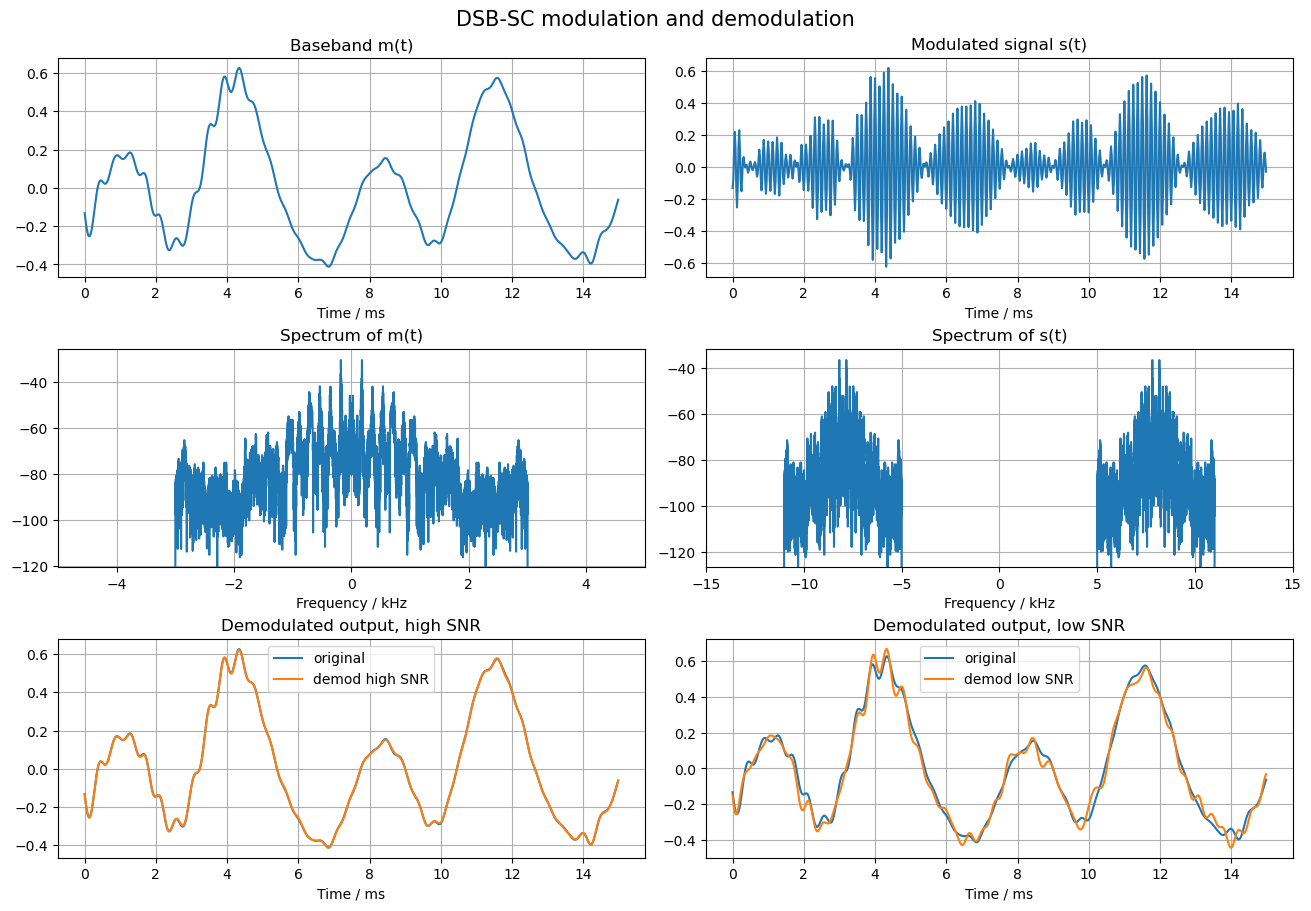

[{'scheme': 'DSB-SC',
  'snr_case': 'high',
  'target_input_snr_db': '30.00',
  'measured_input_snr_db': '29.99',
  'measured_output_snr_db': '38.73'},
 {'scheme': 'DSB-SC',
  'snr_case': 'low',
  'target_input_snr_db': '8.00',
  'measured_input_snr_db': '8.02',
  'measured_output_snr_db': '17.09'}]

In [7]:
dsb_rows = run_case("DSB-SC", dsb_sc_modulate, dsb_sc_demodulate)
dsb_rows

### 4-2 AM 信号的调制解调

关注点：AM 保留载波，可以用包络检波。低信噪比时包络会被噪声扰动，输出 SNR 通常下降明显。

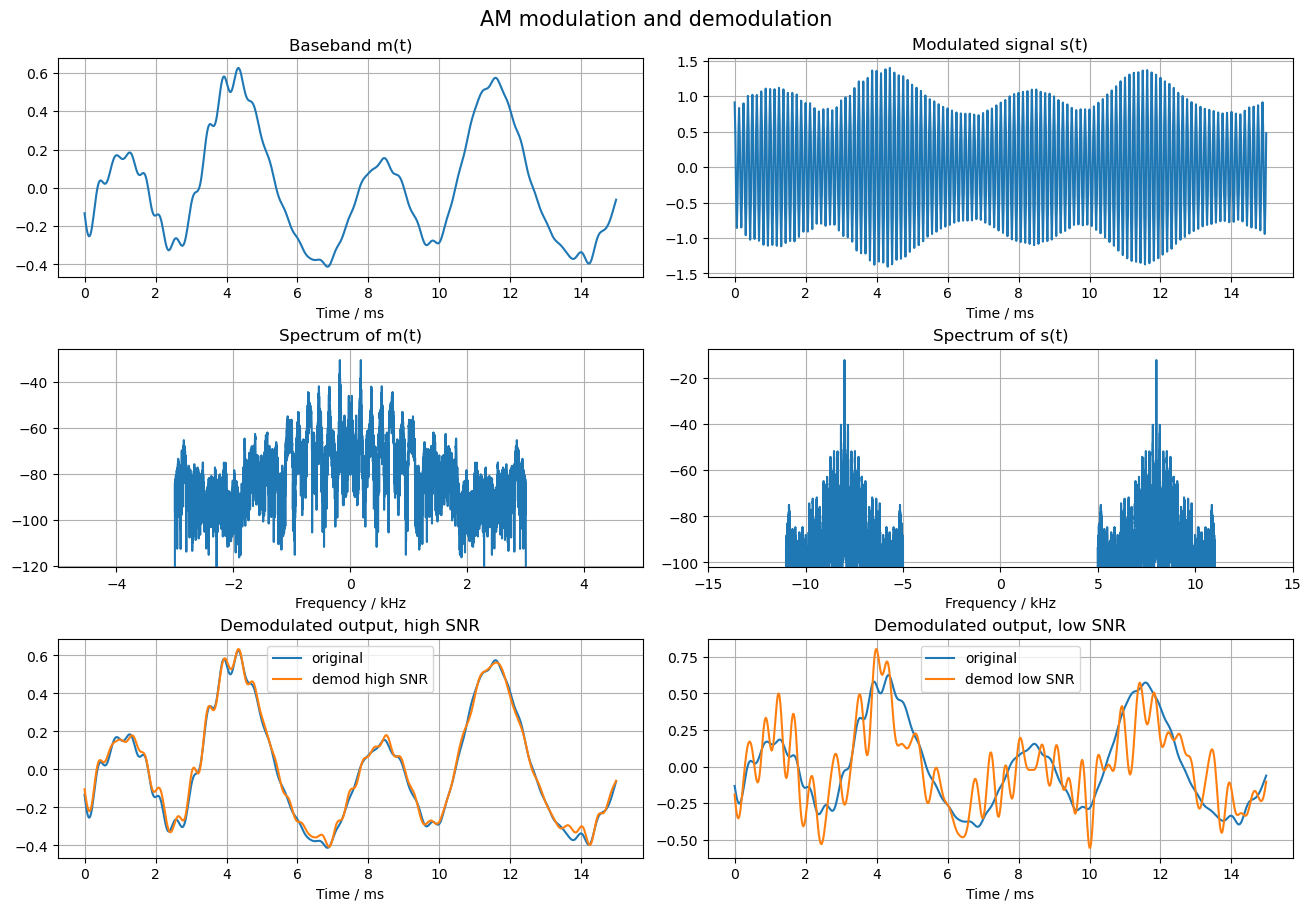

[{'scheme': 'AM',
  'snr_case': 'high',
  'target_input_snr_db': '30.00',
  'measured_input_snr_db': '30.03',
  'measured_output_snr_db': '21.02'},
 {'scheme': 'AM',
  'snr_case': 'low',
  'target_input_snr_db': '8.00',
  'measured_input_snr_db': '8.01',
  'measured_output_snr_db': '2.62'}]

In [8]:
am_rows = run_case("AM", am_modulate, am_envelope_demodulate)
am_rows

### 4-3 SSB 信号的调制解调

关注点：SSB 只保留一个边带。频谱中应主要看到载波附近的一侧边带，因此比 DSB-SC 节省带宽。

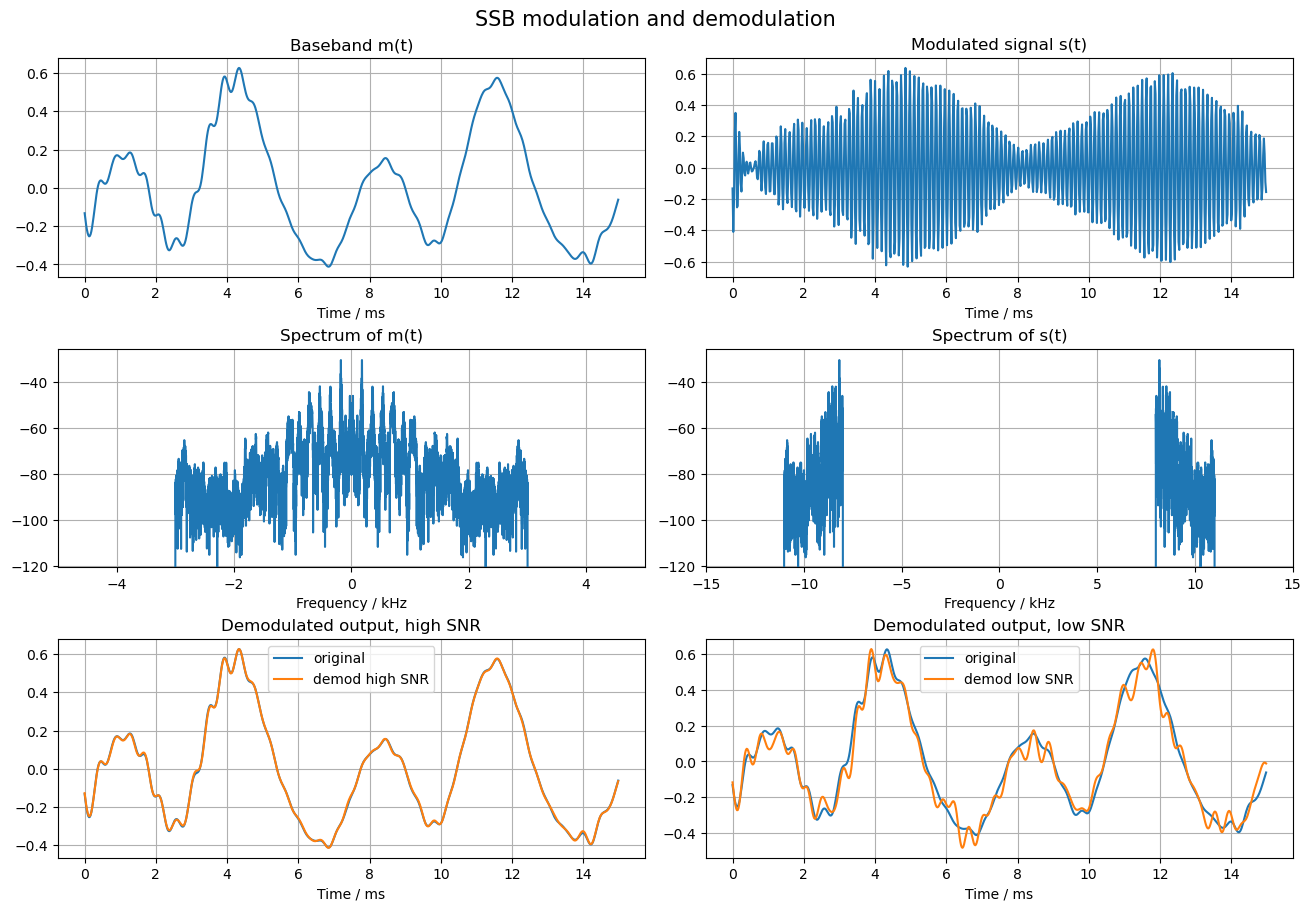

[{'scheme': 'SSB',
  'snr_case': 'high',
  'target_input_snr_db': '30.00',
  'measured_input_snr_db': '30.00',
  'measured_output_snr_db': '35.97'},
 {'scheme': 'SSB',
  'snr_case': 'low',
  'target_input_snr_db': '8.00',
  'measured_input_snr_db': '7.98',
  'measured_output_snr_db': '14.12'}]

In [9]:
ssb_rows = run_case("SSB", ssb_modulate_usb, ssb_demodulate)
ssb_rows

### 4-4 FM 信号的调制解调

关注点：FM 的幅度基本恒定，信息在瞬时频率里。Carson 公式估算带宽：

`B ≈ 2(Δf + W)`

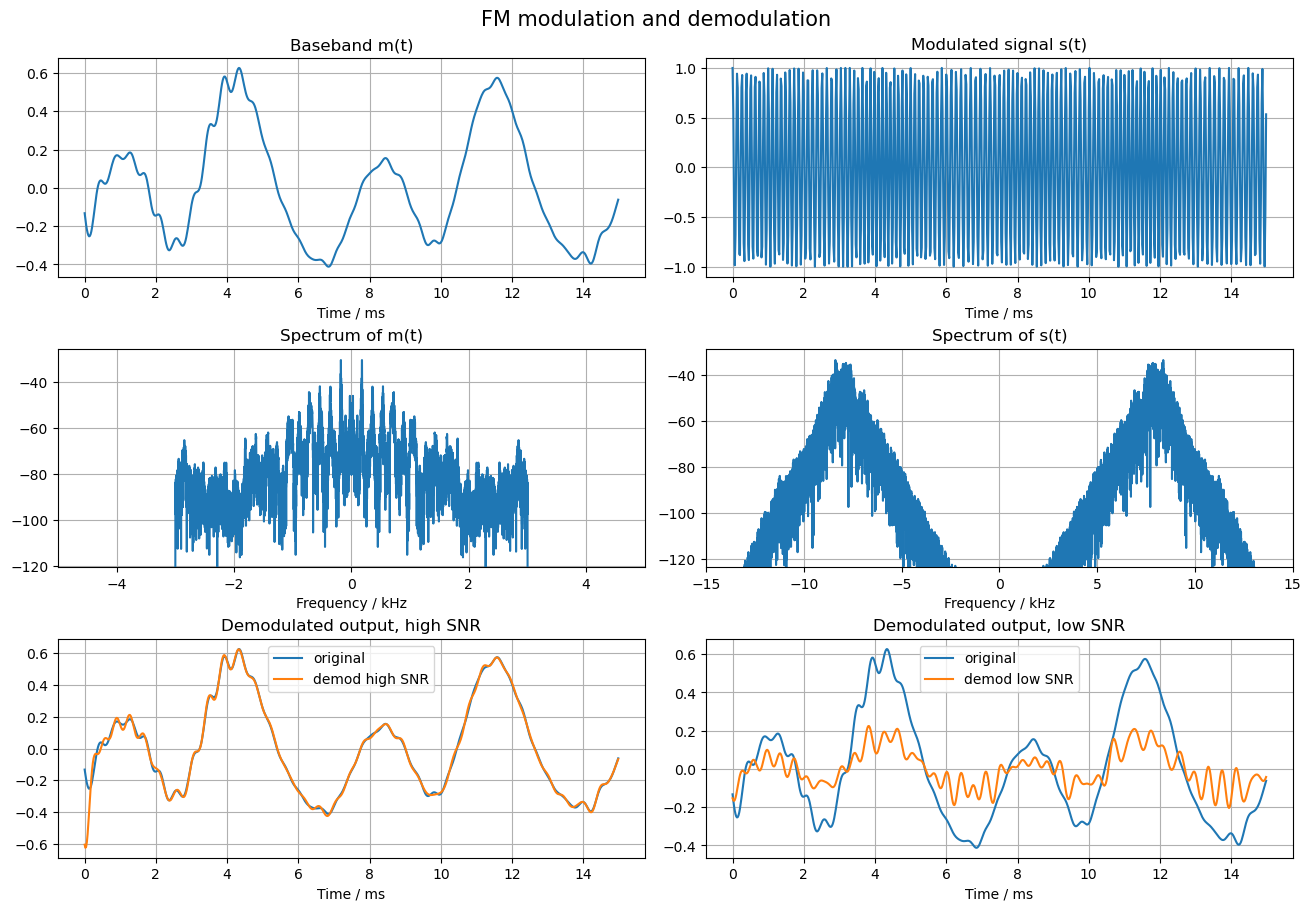

FM Carson bandwidth estimate: 9600.0 Hz


[{'scheme': 'FM',
  'snr_case': 'high',
  'target_input_snr_db': '30.00',
  'measured_input_snr_db': '30.01',
  'measured_output_snr_db': '25.86'},
 {'scheme': 'FM',
  'snr_case': 'low',
  'target_input_snr_db': '8.00',
  'measured_input_snr_db': '8.01',
  'measured_output_snr_db': '2.75'}]

In [10]:
fm_rows = run_case("FM", fm_modulate, fm_demodulate)
fm_bandwidth = 2 * (cfg.fm_frequency_deviation + cfg.message_bandwidth)
print(f"FM Carson bandwidth estimate: {fm_bandwidth:.1f} Hz")
fm_rows

## 8. 汇总输入/输出信噪比

输入 SNR 是已调信号 `s(t)` 与加噪接收信号 `r(t)` 的比较；输出 SNR 是原始基带 `m(t)` 与解调输出的比较。

输出 SNR 不一定等于输入 SNR，因为不同调制解调方式、滤波和非线性检波会改变噪声影响。

In [11]:
all_rows = dsb_rows + am_rows + ssb_rows + fm_rows

for row in all_rows:
    print(
        f"{row['scheme']:6s} {row['snr_case']:4s} | "
        f"target input SNR = {row['target_input_snr_db']:>5s} dB | "
        f"measured input SNR = {row['measured_input_snr_db']:>5s} dB | "
        f"output SNR = {row['measured_output_snr_db']:>5s} dB"
    )

csv_path = out_dir / "snr_results.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_rows)

print(f"\nSaved SNR table to {csv_path.resolve()}")

DSB-SC high | target input SNR = 30.00 dB | measured input SNR = 29.99 dB | output SNR = 38.73 dB
DSB-SC low  | target input SNR =  8.00 dB | measured input SNR =  8.02 dB | output SNR = 17.09 dB
AM     high | target input SNR = 30.00 dB | measured input SNR = 30.03 dB | output SNR = 21.02 dB
AM     low  | target input SNR =  8.00 dB | measured input SNR =  8.01 dB | output SNR =  2.62 dB
SSB    high | target input SNR = 30.00 dB | measured input SNR = 30.00 dB | output SNR = 35.97 dB
SSB    low  | target input SNR =  8.00 dB | measured input SNR =  7.98 dB | output SNR = 14.12 dB
FM     high | target input SNR = 30.00 dB | measured input SNR = 30.01 dB | output SNR = 25.86 dB
FM     low  | target input SNR =  8.00 dB | measured input SNR =  8.01 dB | output SNR =  2.75 dB

Saved SNR table to D:\steven\work\DSBSCAMSSBFM\outputs_notebook\snr_results.csv
